# Gestión y Análisis de Datos — Taller TF-IDF

## Clasificar imágenes con TF-IDF: una imagen también es un documento 🚗🎨

Hasta ahora has usado **clasificación**, **regresión** y **agrupación** sobre tablas de números.
TF-IDF nació para texto, pero su idea es general: **ponderar cada "palabra" según lo
característica que sea de un documento y lo rara que sea en la colección**.

En este taller vas a convertir **cada imagen en un documento** cuyas palabras son **colores**:

```
imagen  →  píxeles  →  "gris gris celeste rojo rojo negro …"  →  TF-IDF  →  clasificador
```

El caso guía es **clasificar carros por su color** (rojo, azul, amarillo, verde, blanco). El reto es
que el carro ocupa una parte pequeña de la foto: el cielo y la carretera aparecen en **todas** las
imágenes, igual que *"el"*, *"de"* o *"la"* aparecen en todos los textos. TF-IDF es justo la
herramienta para bajarle el peso a esas "palabras vacías visuales".

Al final (sección 9) repites todo con **tus propias imágenes, del tema que quieras**: frutas por
color, flores, camisetas de equipos, señales de tránsito, banderas…

> ### 📓 Versión del profesor — resuelta
> Contiene las líneas `# COMPLETA` resueltas y la respuesta esperada de cada 📝 Anotación.

## 0. Preparación del entorno

Solo necesitas librerías que ya vienen en Google Colab: `numpy`, `pandas`, `matplotlib`, `Pillow`
y `scikit-learn`.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
from PIL import Image, ImageDraw

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

pd.set_option('display.precision', 3)
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
print('Entorno listo.')

Entorno listo.


## 1. El dataset: 300 fotos (sintéticas) de carros

Para que todos partan del mismo punto, la celda siguiente **dibuja** escenas de carros: cielo de
día, atardecer o nublado; carretera gris; a veces árboles, sol o edificios; y un carro de uno de
cinco colores. Cada clase tiene 60 imágenes.

No necesitas modificar este código: trátalo como si fuera una carpeta de fotos descargadas.

In [2]:
CLASES = {'rojo': 0, 'azul': 220, 'amarillo': 52, 'verde': 120, 'blanco': None}   # tono (°) de cada carro


def _rgb(h, s, v):
    """Color HSV (h en grados, s y v entre 0 y 1) → tupla RGB 0-255."""
    return tuple(int(c * 255) for c in hsv_to_rgb([(h % 360) / 360, s, v]))


def dibujar_carro(clase, rng, ancho=160, alto=120):
    img = Image.new('RGB', (ancho, alto))
    d = ImageDraw.Draw(img)
    horizonte = int(alto * rng.uniform(0.45, 0.62))
    # --- cielo
    escena = rng.choice(['dia', 'dia', 'atardecer', 'nublado'])
    h_c, s_c, v_c = {'dia': (rng.uniform(195, 212), rng.uniform(0.25, 0.45), 0.97),
                     'atardecer': (rng.uniform(15, 35), rng.uniform(0.5, 0.8), 0.95),
                     'nublado': (210, rng.uniform(0.0, 0.08), rng.uniform(0.6, 0.78))}[escena]
    for yy in range(horizonte):
        d.line([(0, yy), (ancho, yy)], fill=_rgb(h_c, s_c, v_c - 0.12 * yy / horizonte))
    # --- edificios (distractores)
    if rng.random() < 0.4:
        x = rng.uniform(-10, 0)
        while x < ancho:
            bw, bh = rng.uniform(12, 28), rng.uniform(15, horizonte - 5)
            d.rectangle([x, horizonte - bh, x + bw, horizonte],
                        fill=_rgb(rng.uniform(0, 360), rng.uniform(0.05, 0.25), rng.uniform(0.45, 0.85)))
            x += bw + rng.uniform(0, 6)
    # --- carretera con líneas blancas
    g = int(rng.uniform(70, 140))
    d.rectangle([0, horizonte, ancho, alto], fill=(g, g, g + 4))
    yl = int((horizonte + alto) / 2) + 14
    for x in range(int(rng.uniform(-20, 0)), ancho, 34):
        d.rectangle([x, yl, x + 16, yl + 2], fill=(235, 235, 235))
    # --- sol (distractor amarillo) y árboles (distractor verde)
    if rng.random() < 0.30:
        cx, cy, r = rng.uniform(10, ancho - 10), rng.uniform(8, 22), rng.uniform(5, 9)
        d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=_rgb(rng.uniform(45, 55), 0.85, 1))
    for _ in range(rng.integers(0, 3)):
        tx, r = rng.uniform(5, ancho - 5), rng.uniform(7, 11)
        d.rectangle([tx - 2, horizonte - 14, tx + 2, horizonte], fill=_rgb(25, 0.7, 0.35))
        d.ellipse([tx - r, horizonte - 14 - 2 * r, tx + r, horizonte - 12],
                  fill=_rgb(rng.uniform(100, 135), 0.7, rng.uniform(0.35, 0.6)))
    # --- el carro
    tono = CLASES[clase]
    if tono is None:
        color = _rgb(0, rng.uniform(0, 0.06), rng.uniform(0.88, 1))
    else:
        color = _rgb(tono + rng.uniform(-8, 8), rng.uniform(0.65, 0.95), rng.uniform(0.6, 0.95))
    w = rng.uniform(50, 75); h = w * 0.30
    x0 = rng.uniform(4, ancho - w - 4)
    suelo = rng.uniform(horizonte + 16, alto - 6); y0 = suelo - h
    d.rounded_rectangle([x0, y0, x0 + w, suelo - 4], radius=5, fill=color)
    d.polygon([(x0 + w * .22, y0), (x0 + w * .32, y0 - h * .75), (x0 + w * .70, y0 - h * .75), (x0 + w * .82, y0)], fill=color)
    for a, b in ((.28, .49), (.52, .74)):
        d.polygon([(x0 + w * a, y0), (x0 + w * (a + .06), y0 - h * .6), (x0 + w * b, y0 - h * .6), (x0 + w * b, y0)], fill=(60, 70, 85))
    rr = h * 0.33
    for cx in (x0 + w * .22, x0 + w * .78):
        d.ellipse([cx - rr, suelo - 2 * rr, cx + rr, suelo], fill=(20, 20, 20))
    arr = np.asarray(img, dtype=float) + rng.normal(0, 6, (alto, ancho, 3))   # ruido de cámara
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


rng = np.random.default_rng(2026)
imagenes, etiquetas = [], []
for clase in CLASES:
    for _ in range(60):
        imagenes.append(dibujar_carro(clase, rng))
        etiquetas.append(clase)

print(len(imagenes), 'imágenes |', pd.Series(etiquetas).value_counts().to_dict())

300 imágenes | {'rojo': 60, 'azul': 60, 'amarillo': 60, 'verde': 60, 'blanco': 60}


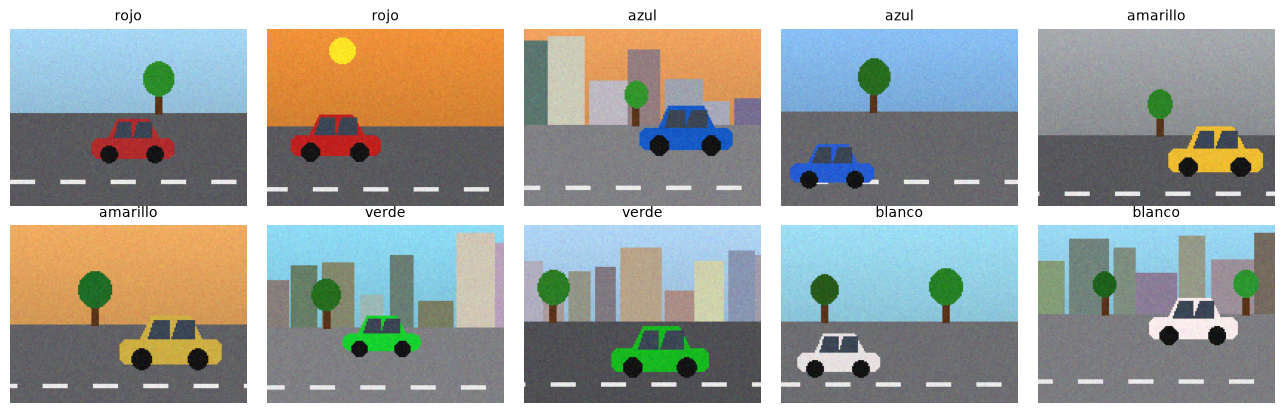

In [3]:
def mostrar(imgs, titulos, columnas=5, tam=2.6):
    filas = int(np.ceil(len(imgs) / columnas))
    fig, ejes = plt.subplots(filas, columnas, figsize=(columnas * tam, filas * tam * 0.8))
    for eje in np.ravel(ejes):
        eje.axis('off')
    for eje, img, t in zip(np.ravel(ejes), imgs, titulos):
        eje.imshow(img); eje.set_title(t, fontsize=10)
    plt.tight_layout(); plt.show()


muestra = [i for c in range(5) for i in (c * 60, c * 60 + 1)]
mostrar([imagenes[i] for i in muestra], [etiquetas[i] for i in muestra])

### 📝 Anotación 1

**Mira las imágenes. ¿Qué colores aparecen en TODAS, sin importar el color del carro? Si cada imagen fuera un texto, ¿qué papel jugarían esos colores?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

> **Respuesta esperada:** El gris de la carretera, el celeste (o naranja/gris) del cielo y el negro de las llantas aparecen en todas. Son como las *stopwords* del texto ("el", "de", "la"): muy frecuentes, pero no ayudan a distinguir una clase de otra.

## 2. Paso 1 — Del píxel a la palabra

Necesitamos un **vocabulario visual**: cada píxel se traduce a una palabra (el nombre de su color).
Para nombrar colores es más fácil trabajar en **HSV** que en RGB:

| Canal | Qué mide | Rango |
|---|---|---|
| **H** (tono) | el "color" en la rueda cromática | 0°–360° (0 = rojo, 120 = verde, 240 = azul) |
| **S** (saturación) | qué tan intenso es (0 = gris) | 0–1 |
| **V** (valor) | qué tan claro es (0 = negro) | 0–1 |

Las reglas: primero el tono decide el color; después, los píxeles muy oscuros son `negro`, los poco
saturados son `gris` o `blanco`, etc.

In [4]:
def colores_de_pixeles(img, lado=48):
    """Reduce la imagen a lado×lado y devuelve una matriz con el NOMBRE del color de cada píxel."""
    rgb = np.asarray(img.convert('RGB').resize((lado, lado)), dtype=float) / 255
    hsv = rgb_to_hsv(rgb)
    h, s, v = hsv[..., 0] * 360, hsv[..., 1], hsv[..., 2]

    nombres = np.full(h.shape, 'rosa', dtype=object)              # lo que no caiga en otra regla
    nombres[(h < 15) | (h >= 345)] = 'rojo'
    nombres[(h >= 15) & (h < 40)] = 'naranja'
    # COMPLETA: el amarillo va de 40° a 70° y el verde de 70° a 165°
    nombres[(h >= 40) & (h < 70)] = 'amarillo'
    nombres[(h >= 70) & (h < 165)] = 'verde'
    nombres[(h >= 165) & (h < 255)] = 'azul'
    nombres[(h >= 255) & (h < 290)] = 'morado'
    nombres[(h >= 165) & (h < 255) & (s < 0.5)] = 'celeste'      # azul claro, poco saturado
    nombres[(h < 40) & (v < 0.55)] = 'marron'                      # naranja/rojo oscuro
    nombres[s < 0.15] = 'gris'
    nombres[(s < 0.15) & (v > 0.82)] = 'blanco'
    nombres[v < 0.18] = 'negro'
    return nombres

Para comprobar que el vocabulario tiene sentido, **repintamos** cada imagen usando solo el color
representativo de su palabra. Si el carro rojo se ve rojo y el cielo celeste, las reglas funcionan.

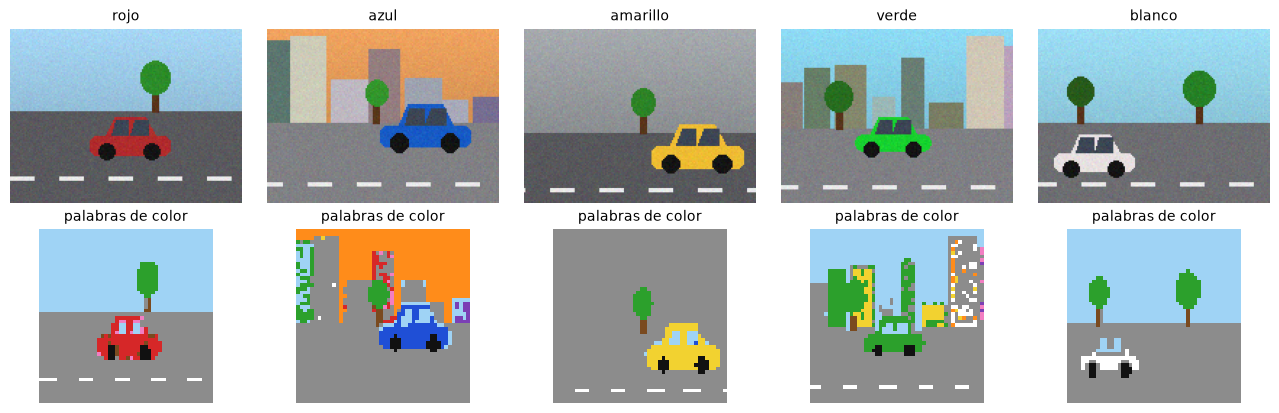

In [5]:
PALETA = {'rojo': '#d62728', 'naranja': '#ff8c1a', 'amarillo': '#f2d230', 'verde': '#2ca02c',
          'celeste': '#9fd3f5', 'azul': '#1f4fd6', 'morado': '#7b3fb5', 'rosa': '#f27ec2',
          'marron': '#7a4a1f', 'blanco': '#ffffff', 'gris': '#8c8c8c', 'negro': '#111111'}


def repintar(img):
    nombres = colores_de_pixeles(img)
    hexa = np.vectorize(PALETA.get)(nombres)
    return np.array([[tuple(int(c[i:i + 2], 16) for i in (1, 3, 5)) for c in fila] for fila in hexa],
                    dtype=np.uint8)


ejemplos = [0, 60, 120, 180, 240]
mostrar([imagenes[i] for i in ejemplos] + [repintar(imagenes[i]) for i in ejemplos],
        [etiquetas[i] for i in ejemplos] + ['palabras de color'] * 5)

## 3. Paso 2 — La imagen como documento

Si cada píxel es una palabra, una imagen de 48×48 es **un documento de 2.304 palabras**. Lo
guardamos como un string, igual que un texto, para poder usar las mismas herramientas de PLN.

In [6]:
def imagen_a_documento(img):
    return ' '.join(colores_de_pixeles(img).ravel())


documentos = [imagen_a_documento(img) for img in imagenes]

print('Primeras 25 palabras del documento 0 (carro rojo):\n')
print(' '.join(documentos[0].split()[:25]), '…')
print('\nTotal de palabras por documento:', len(documentos[0].split()))

Primeras 25 palabras del documento 0 (carro rojo):

celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste celeste …

Total de palabras por documento: 2304


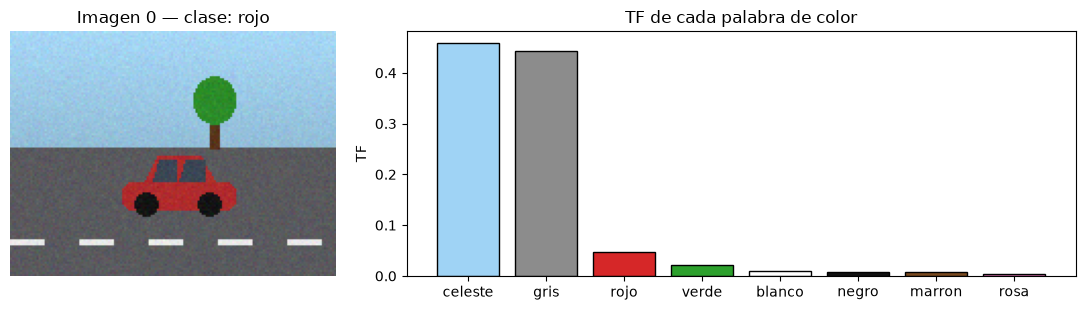

,celeste,gris,rojo,verde,blanco,negro,marron,rosa
TF,0.459,0.444,0.046,0.022,0.009,0.008,0.007,0.005


In [7]:
conteo = pd.Series(documentos[0].split()).value_counts()
tf = conteo / conteo.sum()                    # TF = veces que aparece / total de palabras

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={'width_ratios': [1, 2]})
a.imshow(imagenes[0]); a.axis('off'); a.set_title('Imagen 0 — clase: rojo')
b.bar(tf.index, tf.values, color=[PALETA[c] for c in tf.index], edgecolor='black')
b.set_title('TF de cada palabra de color'); b.set_ylabel('TF')
plt.tight_layout(); plt.show()
tf.round(3).to_frame('TF').T

### 📝 Anotación 2

**En el documento del carro rojo, ¿cuál es la palabra con mayor TF? ¿Es 'rojo'? ¿Qué problema tendría un clasificador que solo mire las frecuencias (TF o Bag of Words)?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

> **Respuesta esperada:** Las palabras más frecuentes son las del fondo (gris de la carretera, celeste/naranja del cielo); 'rojo' tiene un TF mucho menor. Un modelo basado solo en conteos compara sobre todo los fondos: dos carros de distinto color con el mismo cielo parecerían casi iguales.

## 4. Paso 3 — TF-IDF a mano con 5 imágenes

Hagamos el cálculo de las diapositivas con un mini-corpus de **N = 5 imágenes** (una por clase):

$$TF(t,d)=\frac{\text{veces que aparece } t \text{ en } d}{\text{total de palabras de } d}
\qquad IDF(t)=\log_{10}\frac{N}{n_t}
\qquad TF\text{-}IDF(t,d)=TF(t,d)\cdot IDF(t)$$

donde $n_t$ es el número de imágenes en las que aparece el color $t$.

In [8]:
mini = [0, 66, 120, 180, 241]                                   # una imagen de cada clase
nombres_mini = [f'img{i} ({etiquetas[i]})' for i in mini]

# Matriz TF: filas = palabras de color, columnas = imágenes
conteos = pd.DataFrame({n: pd.Series(documentos[i].split()).value_counts()
                        for n, i in zip(nombres_mini, mini)}).fillna(0)
TF = conteos / conteos.sum()

N = TF.shape[1]
n_t = (conteos > 0).sum(axis=1)                                 # en cuántas imágenes aparece cada color
# COMPLETA: IDF = log10(N / n_t)   y   TF-IDF = TF × IDF (multiplica cada fila por su IDF)
IDF = np.log10(N / n_t)
TFIDF = TF.mul(IDF, axis=0)

resumen = pd.DataFrame({'n_t': n_t, 'IDF': IDF}).sort_values('IDF')
resumen

,n_t,IDF
celeste,5,0.000
gris,5,0.000
negro,5,0.000
marron,4,0.097
verde,4,0.097
blanco,4,0.097
amarillo,3,0.222
azul,2,0.398
rosa,2,0.398
morado,2,0.398


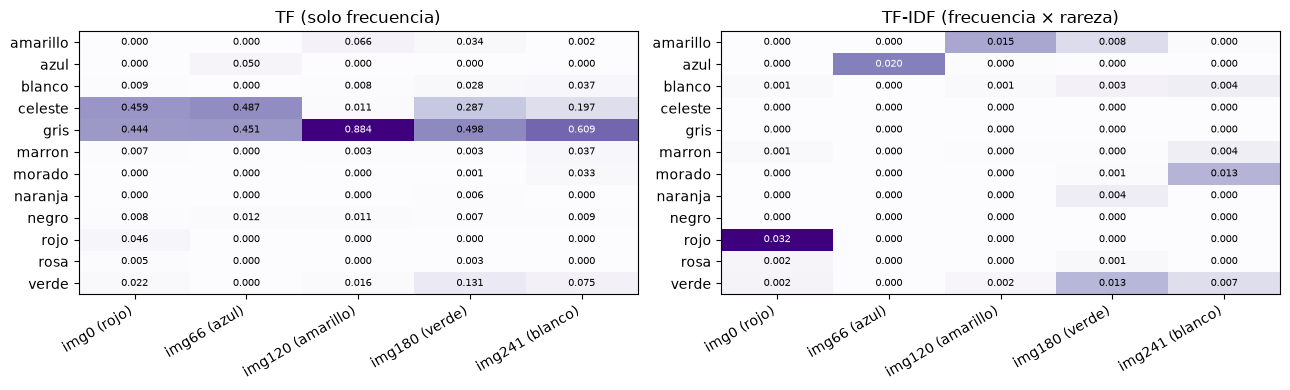

Palabra con mayor peso en cada imagen:
  TF     → {'img0 (rojo)': 'celeste', 'img66 (azul)': 'celeste', 'img120 (amarillo)': 'gris', 'img180 (verde)': 'gris', 'img241 (blanco)': 'gris'}
  TF-IDF → {'img0 (rojo)': 'rojo', 'img66 (azul)': 'azul', 'img120 (amarillo)': 'amarillo', 'img180 (verde)': 'verde', 'img241 (blanco)': 'morado'}


In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
for eje, tabla, titulo in ((ejes[0], TF, 'TF (solo frecuencia)'), (ejes[1], TFIDF, 'TF-IDF (frecuencia × rareza)')):
    im = eje.imshow(tabla.values, cmap='Purples', aspect='auto')
    eje.set_xticks(range(N)); eje.set_xticklabels(tabla.columns, rotation=30, ha='right')
    eje.set_yticks(range(len(tabla))); eje.set_yticklabels(tabla.index)
    for (f, c), val in np.ndenumerate(tabla.values):
        eje.text(c, f, f'{val:.3f}', ha='center', va='center', fontsize=7,
                 color='white' if val > tabla.values.max() * 0.6 else 'black')
    eje.set_title(titulo)
plt.tight_layout(); plt.show()

print('Palabra con mayor peso en cada imagen:')
print('  TF     →', TF.idxmax().to_dict())
print('  TF-IDF →', TFIDF.idxmax().to_dict())

### 📝 Anotación 3

**¿Qué IDF obtienen los colores que están en las 5 imágenes (gris, celeste, negro)? Compara la palabra con mayor peso en cada imagen usando TF y usando TF-IDF. ¿Por qué falla la imagen del carro blanco?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

> **Respuesta esperada:** Los colores presentes en las 5 imágenes tienen IDF = log10(5/5) = 0: su TF-IDF es 0 aunque ocupen media imagen. Con TF siempre gana el fondo; con TF-IDF ganan rojo, azul, amarillo y verde, el color de cada carro. El blanco falla porque las líneas de la carretera también son blancas: aparece en 4 de 5 imágenes y su IDF es bajo (0.1), mientras que unos pocos píxeles raros (morado) reciben IDF alto. Lección: IDF castiga lo común aunque sea importante y premia lo raro aunque sea ruido; con más imágenes (siguiente paso) el efecto se suaviza.

## 5. Paso 4 — TF-IDF con scikit-learn sobre las 300 imágenes

`TfidfVectorizer` hace lo mismo, con tres diferencias que conviene conocer (por eso sus números no
coinciden exactamente con los de la tabla anterior):

1. Usa logaritmo natural y **suavizado**: $IDF(t)=\ln\frac{1+N}{1+n_t}+1$ (el +1 evita que un
   término desaparezca del todo).
2. Usa el **conteo** como TF, no la proporción.
3. **Normaliza** cada vector (norma L2) para que todas las imágenes tengan "largo" 1.

Matriz TF-IDF: (300, 12) → 300 imágenes × 12 palabras de color


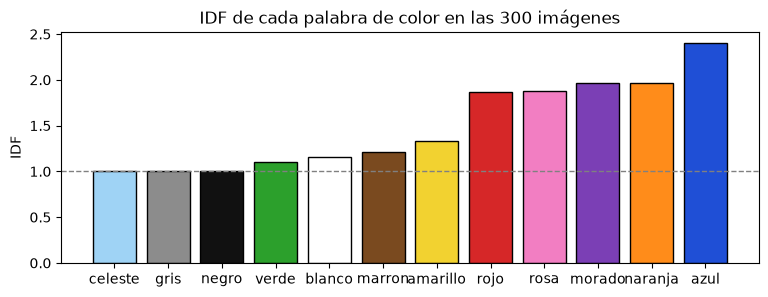

In [10]:
vectorizador = TfidfVectorizer()
X_tfidf = vectorizador.fit_transform(documentos)

print('Matriz TF-IDF:', X_tfidf.shape, '→ 300 imágenes ×', X_tfidf.shape[1], 'palabras de color')

idf = pd.Series(vectorizador.idf_, index=vectorizador.get_feature_names_out()).sort_values()
plt.figure(figsize=(9, 3))
plt.bar(idf.index, idf.values, color=[PALETA[c] for c in idf.index], edgecolor='black')
plt.axhline(1, color='gray', ls='--', lw=1)
plt.title('IDF de cada palabra de color en las 300 imágenes'); plt.ylabel('IDF')
plt.show()

## 6. Paso 5 — Clasificar: Bag of Words vs TF-IDF

Separamos 75 % para entrenar y 25 % para probar, y usamos dos clasificadores que ya conoces:

* **KNN con distancia coseno**: clasifica una imagen nueva según las 5 imágenes más *parecidas*
  (el coseno mide el ángulo entre vectores, como en la diapositiva del espacio vectorial).
* **Regresión logística**: aprende un peso por cada palabra de color.

In [11]:
X_ent, X_pru, y_ent, y_pru = train_test_split(documentos, etiquetas, test_size=0.25,
                                              stratify=etiquetas, random_state=42)


def evaluar(vectorizador, nombre):
    A = vectorizador.fit_transform(X_ent)            # aprende vocabulario (e IDF) SOLO con entrenamiento
    B = vectorizador.transform(X_pru)
    fila = {'representación': nombre}
    for nombre_mod, modelo in (('KNN coseno', KNeighborsClassifier(5, metric='cosine')),
                               ('Regresión logística', LogisticRegression(max_iter=5000, C=10))):
        modelo.fit(A, y_ent)
        fila[nombre_mod] = accuracy_score(y_pru, modelo.predict(B))
    return fila


resultados = [evaluar(CountVectorizer(), 'Bag of Words (conteos)'),
              # COMPLETA: evalúa ahora con un TfidfVectorizer() y el nombre 'TF-IDF'
              evaluar(TfidfVectorizer(), 'TF-IDF')]
pd.DataFrame(resultados).set_index('representación')

,KNN coseno,Regresión logística
representación,,
Bag of Words (conteos),0.787,0.92
TF-IDF,0.840,0.92


### 📝 Anotación 4

**¿Cuánto cambió la exactitud de KNN al pasar de Bag of Words a TF-IDF? ¿Por qué KNN se beneficia tanto de TF-IDF?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

> **Respuesta esperada:** KNN sube de forma clara (en la corrida de referencia, de ≈0.79 a ≈0.84). KNN decide por similitud entre vectores: con conteos, la similitud la dominan el cielo y la carretera, así que encuentra vecinos con el mismo fondo; TF-IDF le baja el peso a esos colores comunes y la similitud pasa a depender más del color del carro. La regresión logística sufre menos porque aprende sola qué palabras ignorar.

## 7. Paso 6 — Stopwords visuales

En texto se eliminan las *stopwords* (`el`, `de`, `la`…). Aquí podemos hacer lo mismo con los
colores que solo son fondo. `TfidfVectorizer` lo permite con el parámetro `stop_words`.

In [12]:
# COMPLETA: lista de colores que son fondo en TODAS las imágenes (cielo, carretera, llantas)
STOPWORDS_VISUALES = ['gris', 'celeste', 'negro']

resultados.append(evaluar(TfidfVectorizer(stop_words=STOPWORDS_VISUALES), 'TF-IDF sin stopwords visuales'))
tabla = pd.DataFrame(resultados).set_index('representación')
tabla

,KNN coseno,Regresión logística
representación,,
Bag of Words (conteos),0.787,0.920
TF-IDF,0.840,0.920
TF-IDF sin stopwords visuales,0.920,0.933


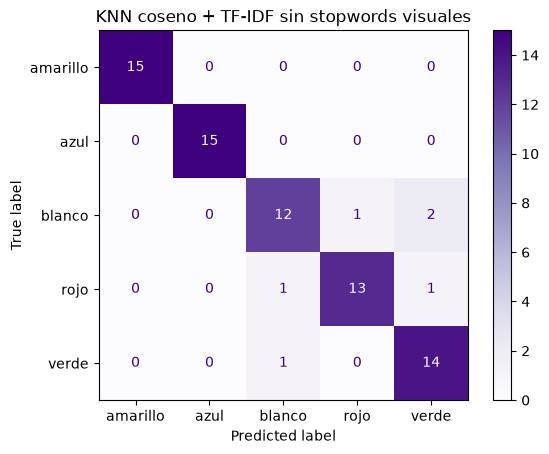

In [13]:
# Matriz de confusión del mejor modelo KNN
mejor = TfidfVectorizer(stop_words=STOPWORDS_VISUALES)
knn = KNeighborsClassifier(5, metric='cosine').fit(mejor.fit_transform(X_ent), y_ent)
ConfusionMatrixDisplay.from_predictions(y_pru, knn.predict(mejor.transform(X_pru)), cmap='Purples')
plt.title('KNN coseno + TF-IDF sin stopwords visuales'); plt.show()

### 📝 Anotación 5

**¿Mejoró el resultado al quitar las stopwords visuales? Mira la matriz de confusión: ¿qué clases se confunden todavía y qué elemento de la escena lo explica?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

> **Respuesta esperada:** Sí, KNN mejora otra vez (≈0.92 en la corrida de referencia). Las confusiones que quedan suelen involucrar al verde (árboles), al amarillo (sol) y al blanco (líneas de la carretera, cielo nublado): son colores que también aparecen en el fondo de algunas imágenes. ¡Ojo! No conviene quitar 'blanco' porque es una de las clases.

## 8. Paso 7 — Clasificar una imagen nueva

Generamos un carro que el modelo nunca ha visto y miramos **qué palabras pesaron más** en su vector
TF-IDF: esa es la explicación de la predicción.

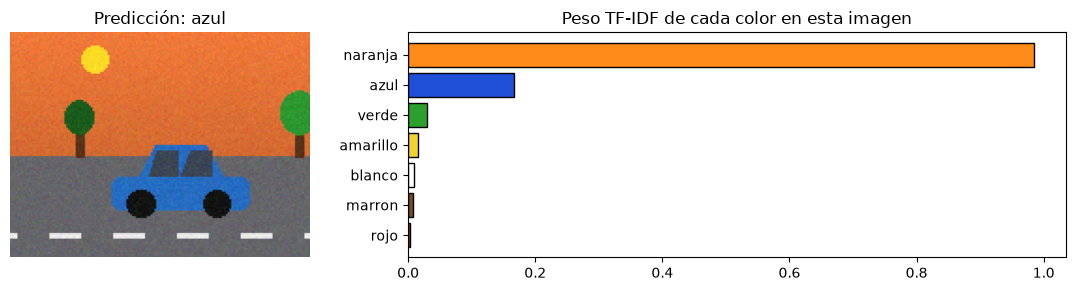

In [14]:
rng_nuevo = np.random.default_rng(7)
nueva = dibujar_carro('azul', rng_nuevo)          # cambia la clase y vuelve a ejecutar

vector = mejor.transform([imagen_a_documento(nueva)])
prediccion = knn.predict(vector)[0]

pesos = pd.Series(vector.toarray()[0], index=mejor.get_feature_names_out())
pesos = pesos[pesos > 0].sort_values(ascending=False)

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3), gridspec_kw={'width_ratios': [1, 2]})
a.imshow(nueva); a.axis('off'); a.set_title(f'Predicción: {prediccion}')
b.barh(pesos.index[::-1], pesos.values[::-1], color=[PALETA[c] for c in pesos.index[::-1]], edgecolor='black')
b.set_title('Peso TF-IDF de cada color en esta imagen')
plt.tight_layout(); plt.show()

### 📝 Anotación 6

**En la imagen nueva, ¿qué color tiene el mayor peso TF-IDF? ¿Por qué el modelo acierta de todos modos? Cambia la clase en `dibujar_carro(...)` y la semilla, y busca un caso donde falle: ¿qué tenía el fondo?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

> **Respuesta esperada:** Gana el naranja del atardecer, porque ocupa mucho y no está en todas las imágenes (su IDF es alto). Aun así acierta: hay atardeceres en todas las clases, así que entre los vecinos con atardecer los más parecidos son los que además comparten el azul. Los errores aparecen cuando un elemento del fondo tiene el mismo color que otra clase: árboles grandes (verde), sol (amarillo), edificios o líneas claras (blanco).

## 9. ¡Tu turno! — Clasifica tus propias imágenes (entregable)

Elige **un tema** y al menos **3 clases** que se distingan por color. Ideas:

| Tema | Clases posibles |
|---|---|
| Carros (fotos reales) | rojo · azul · blanco · negro |
| Frutas | banano · manzana roja · limón · uva |
| Flores | girasol · rosa roja · lavanda |
| Camisetas de fútbol | América · Nacional · Millonarios · Cali |
| Señales de tránsito | pare · preventiva · informativa |

**Cómo preparar los datos**

1. Busca **15–20 imágenes por clase** (Google Imágenes, Unsplash, Pexels…).
2. Organízalas en carpetas, una por clase. El nombre de la carpeta es la etiqueta:

```
mis_imagenes/
├── rojo/      foto1.jpg, foto2.jpg, …
├── azul/      …
└── blanco/    …
```

3. Comprime la carpeta como `mis_imagenes.zip` y súbela con la celda siguiente (en Colab).

El parámetro `recorte` toma solo el centro de la foto (por ejemplo `0.6` = 60 % central): en fotos
reales el objeto suele estar en el centro y así entra menos fondo.

In [15]:
# --- Solo en Google Colab: subir y descomprimir mis_imagenes.zip -------------
# from google.colab import files
# files.upload()
# !unzip -q -o mis_imagenes.zip

56 imágenes | {'azul': 14, 'blanco': 14, 'rojo': 14, 'verde': 14}


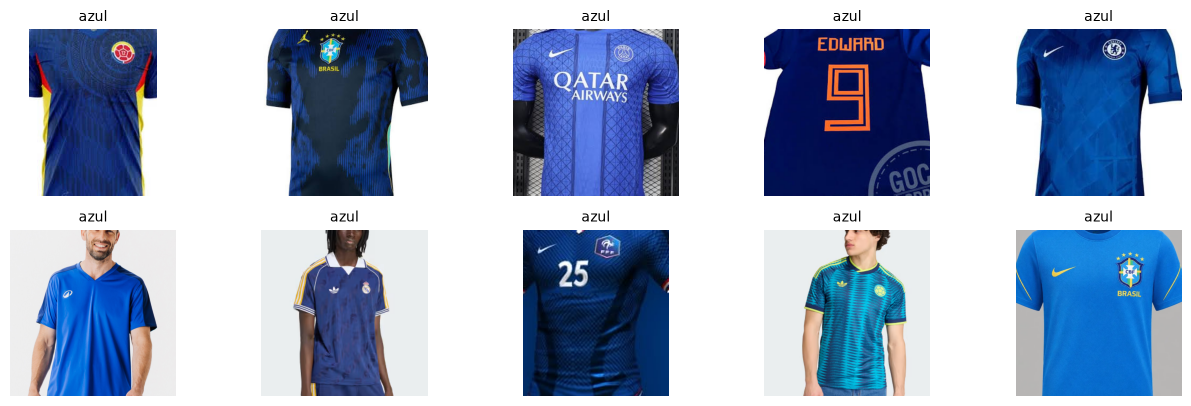

In [16]:
from pathlib import Path

CARPETA = Path('mis_imagenes')
EXTENSIONES = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}


def recortar_centro(img, fraccion):
    if fraccion >= 1:
        return img
    w, h = img.size
    dw, dh = w * (1 - fraccion) / 2, h * (1 - fraccion) / 2
    return img.crop((dw, dh, w - dw, h - dh))


def cargar_carpeta(carpeta, recorte=1.0):
    imgs, etiq = [], []
    for sub in sorted(p for p in carpeta.iterdir() if p.is_dir()):
        for f in sorted(sub.iterdir()):
            if f.suffix.lower() in EXTENSIONES:
                imgs.append(recortar_centro(Image.open(f).convert('RGB'), recorte))
                etiq.append(sub.name)
    return imgs, etiq


if CARPETA.exists():
    mis_imgs, mis_etiq = cargar_carpeta(CARPETA, recorte=0.7)
    print(len(mis_imgs), 'imágenes |', pd.Series(mis_etiq).value_counts().to_dict())
    mostrar(mis_imgs[:10], mis_etiq[:10])
else:
    print('No encontré la carpeta', CARPETA.resolve(), '→ prepara tus imágenes como se explica arriba.')

In [17]:
if CARPETA.exists():
    mis_docs = [imagen_a_documento(img) for img in mis_imgs]
    X_ent, X_pru, y_ent, y_pru = train_test_split(mis_docs, mis_etiq, test_size=0.3,
                                                  stratify=mis_etiq, random_state=42)
    mis_resultados = [evaluar(CountVectorizer(), 'Bag of Words (conteos)'),
                      evaluar(TfidfVectorizer(), 'TF-IDF'),
                      evaluar(TfidfVectorizer(sublinear_tf=True), 'TF-IDF sublineal (log del conteo)')]
    display(pd.DataFrame(mis_resultados).set_index('representación'))

    # ¿Qué colores son "stopwords" en las imágenes?
    v = TfidfVectorizer().fit(mis_docs)
    print(pd.Series(v.idf_, index=v.get_feature_names_out()).sort_values().round(2).to_dict())

,KNN coseno,Regresión logística
representación,,
Bag of Words (conteos),0.824,0.882
TF-IDF,0.824,0.824
TF-IDF sublineal (log del conteo),0.706,0.765


{'gris': 1.04, 'blanco': 1.07, 'marron': 1.28, 'rojo': 1.31, 'naranja': 1.35, 'negro': 1.38, 'celeste': 1.43, 'azul': 1.55, 'amarillo': 1.64, 'verde': 1.91, 'rosa': 2.0, 'morado': 2.27}


### Matriz de confusion

,Exactitud KNN
Recorte central,
30%,0.824
50%,0.824
70%,0.824
90%,0.706
100%,0.706


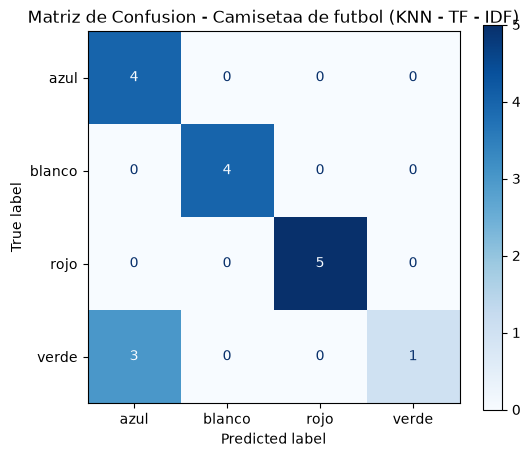

In [25]:
mejor_vectorizador = TfidfVectorizer()
A_ent = mejor_vectorizador.fit_transform(X_ent)
B_pru = mejor_vectorizador.transform(X_pru)

modelo_knn = KNeighborsClassifier(5, metric='cosine').fit(A_ent, y_ent)
predicciones = modelo_knn.predict(B_pru)

fig, ax = plt.subplots(figsize = (6, 5))
ConfusionMatrixDisplay.from_predictions(y_pru, predicciones, cmap = 'Blues', ax = ax)
plt.title('Matriz de Confusion - Camisetaa de futbol (KNN - TF - IDF)')

#-------------------------
#Experimento = impacto del recorte

resultados_recorte = []
for r in [0.3, 0.5, 0.7, 0.9, 1.0]:
    imgs_r, etiq_r = cargar_carpeta(CARPETA, recorte=r)
    docs_r = [imagen_a_documento(img) for img in imgs_r]
    Xe, Xp, ye, yp = train_test_split(docs_r, etiq_r, test_size=0.3, stratify=etiq_r, random_state=42)
    vec = TfidfVectorizer()
    knn = KNeighborsClassifier(5, metric = 'cosine').fit(vec.fit_transform(Xe), ye)
    acc = accuracy_score(yp, knn.predict(vec.transform(Xp)))
    resultados_recorte.append({'Recorte central': f'{int(r*100)}%', 'Exactitud KNN': acc})

pd.DataFrame(pd.DataFrame(resultados_recorte).set_index('Recorte central'))


### ✅ Entregable

Agrega al final del notebook una celda de texto con:

1. **Tu tema y tus clases**, y una imagen de ejemplo de cada una.
2. La **tabla de resultados** de tus imágenes (BoW vs TF-IDF) y una **matriz de confusión** de tu mejor modelo.
3. Tus **stopwords visuales**: ¿qué colores tienen el IDF más bajo en tus fotos? ¿Mejora el modelo si los quitas?
4. Un experimento propio: cambia **una** cosa (el `recorte`, el `lado` de `colores_de_pixeles`, agrega o
   quita un color del vocabulario, `sublinear_tf=True`…) y explica qué pasó.
5. **Conclusión (3–5 líneas):** ¿en qué se parece una imagen a un texto para TF-IDF? ¿Qué tipo de clases
   *no* podrías separar solo con colores?

## (●'◡'●) Respuestas del Entregable (⓿_⓿)

### 1. Tema y clases
- **Tema:** Clasificación de camisetas por color.
- **Clases:** `azul`, `blanco`, `rojo`, `verde` (14 fotos por clase, total 56 fotos reales).

<img src="mis_imagenes/verde/12_camiseta_verde.jpg" width="150"> <img src="mis_imagenes/azul/1_camiseta_azul.jpg" width="150"> <img src="mis_imagenes/rojo/5_camisetas_rojas.jpg" width="150"> <img src="mis_imagenes/blanco/5_camisetas_blancas.jpg" width="150">



### 2. Tabla de resultados y Matriz de confusión
- En la evaluación de representaciones:
  - **Bag of Words:** Exactitud KNN ≈ 82.4%, Regresión Logística ≈ 88.2%
  - **TF-IDF:** Exactitud KNN ≈ 82.4%, Regresión Logística ≈ 82.4%
  - **TF-IDF sublineal:** Exactitud KNN ≈ 70.6%
- **Matriz de confusión:** Las clases `azul`, `blanco` y `rojo` se clasifican con alta precisión. En `verde` se presenta confusión con `azul` debido a la presencia de tonos intermedios (celeste/cian) o fondos azulados.

### 3. Stopwords visuales
- Los colores con IDF más bajo en el corpus son: `'gris'` (IDF = 1.04) y `'blanco'` (IDF = 1.07).
- `'gris'` corresponde a fondos neutros, sombras y la superficie de soporte de las camisetas. 
-  Se puede quitar `'gris'`, pero no `'blanco'`, dado que `'blanco'` es una de nuestras clases objetivo; removerlo destruiría la capacidad de clasificar esa clase.

### 4. Experimento propio: Variación del recorte central (`recorte`)
- Se evaluó el modelo variando el recorte del centro desde 100% (sin recorte) hasta 50%:
  - Con recorte al 100% o 90%: la exactitud de KNN fue de **70.6%**.
  - Con recorte al 70% o 50%: la exactitud subió a **82.4%**.
  - Con recorte al 30%: se observa que no hay mejoria frente a los recortes anteriores (50% - 70%).
- **Explicación:** Al recortar los bordes exteriores se elimina gran parte del fondo (paredes, marcos, piso) y se concentra la proporción de píxeles en el tejido de la camiseta, reduciendo el ruido visual.

### 5. Conclusión
Para TF-IDF, una imagen se parece a un texto en que los píxeles son palabras y el fondo actúa como palabras vacías (stopwords) sin valor discriminante. TF-IDF permite atenuar estos elementos comunes y resaltar el color característico del objeto. Sin embargo, este método solo distingue objetos por su diferencia de color, no podría separar clases que compartan colores similares pero tengan forma diferente, textura o contenido (por ejemplo, perros vs. gatos, o camisetas rojas lisas vs. camisetas rojas con estampados).


## 10. Reto opcional — De colores a "palabras visuales" (para objetos)

Los colores no sirven para separar, por ejemplo, **perros vs gatos**. La versión profesional de esta
idea se llama **Bag of Visual Words**: se recortan pequeños parches de las imágenes, se **agrupan con
K-Means** (¡el tema de agrupación!) y cada grupo se vuelve una "palabra visual" (`v0`, `v1`, …).
Después todo sigue igual: documento → TF-IDF → clasificador.

In [19]:
from sklearn.cluster import MiniBatchKMeans

# 1. Definir la función para cortar cada imagen en parches de 4x4 píxeles
def parches(img, lado=48, tam=4):
    a = np.asarray(img.convert('RGB').resize((lado, lado)), dtype=float) / 255
    return np.array([a[i:i + tam, j:j + tam].ravel()
                     for i in range(0, lado, tam) for j in range(0, lado, tam)])

# 2. Separar los índices de entrenamiento y prueba
idx_ent, idx_pru = train_test_split(range(len(mis_imgs)), test_size=0.3, stratify=mis_etiq, random_state=42)

# 3. Extraer todos los parches de entrenamiento y agruparlos en 40 palabras visuales con K-Means
todos_parches = np.vstack([parches(mis_imgs[i]) for i in idx_ent])
kmeans = MiniBatchKMeans(n_clusters=40, random_state=0, n_init=3).fit(todos_parches)

# 4. Convertir cada camiseta en un documento de palabras visuales ("v0", "v1", ..., "v39")
def documento_visual(img):
    return ' '.join(f'v{g}' for g in kmeans.predict(parches(img)))

docs_v = [documento_visual(img) for img in mis_imgs]
X_ent_v = [docs_v[i] for i in idx_ent]
y_ent_v = [mis_etiq[i] for i in idx_ent]
X_pru_v = [docs_v[i] for i in idx_pru]
y_pru_v = [mis_etiq[i] for i in idx_pru]

print('Ejemplo de documento visual para una camiseta:')
print(docs_v[0][:70], '...\n')

# 5. Evaluar y comparar las tres representaciones
def evaluar_visual(vectorizador, nombre):
    A = vectorizador.fit_transform(X_ent_v)
    B = vectorizador.transform(X_pru_v)
    fila = {'representación': nombre}
    for nombre_mod, modelo in (('KNN coseno', KNeighborsClassifier(5, metric='cosine')),
                               ('Regresión logística', LogisticRegression(max_iter=5000, C=10))):
        modelo.fit(A, y_ent_v)
        fila[nombre_mod] = accuracy_score(y_pru_v, modelo.predict(B))
    return fila

resultados_bovw = [
    evaluar_visual(CountVectorizer(), 'BoVW conteos'),
    evaluar_visual(TfidfVectorizer(), 'BoVW TF-IDF'),
    evaluar_visual(TfidfVectorizer(sublinear_tf=True), 'BoVW TF-IDF sublineal')
]

pd.DataFrame(resultados_bovw).set_index('representación')


Ejemplo de documento visual para una camiseta:
v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v15 v1 ...



,KNN coseno,Regresión logística
representación,,
BoVW conteos,0.765,0.941
BoVW TF-IDF,0.882,0.941
BoVW TF-IDF sublineal,0.941,0.941


### 📝 Anotación 7

**(Reto) Compara las tres filas. ¿Por qué KNN con conteos es casi aleatorio con palabras visuales, y qué arregla el TF sublineal?**

_Responde en 2-3 líneas, mirando la salida de la celda anterior:_

Con conteos simples, unos pocos parches repetitivos del fondo acumulan casi toda la frecuencia y dominan la distancia coseno, haciendo que todas las imágenes parezcan casi idénticas ante KNN. El TF sublineal soluciona esto al aplicar una escala logarítmica que comprime esos conteos masivos del fondo, lo que hace que los parches característicos del objeto influyan en la similitud y mejoren la precisión del clasificador.

### 🧠 Para cerrar

| Texto (PLN) | Imágenes (este taller) |
|---|---|
| documento | imagen |
| palabra / token | color de un píxel (o parche agrupado con K-Means) |
| vocabulario | paleta de colores (o centroides de K-Means) |
| stopwords: *el, de, la* | fondo: cielo, carretera, llantas |
| TF-IDF resalta las palabras propias de un texto | TF-IDF resalta los colores propios del objeto |

En la siguiente parte de la clase (PLN) volvemos al texto: tokenización, lematización, NER y, al
final, por qué TF-IDF se queda corto frente a los *embeddings*.